In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("/kaggle/input/movies-dataset-for-feature-extracion-prediction/movies.csv")
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


# Movie Dataset - Column Descriptions

<table style="width:100%; border-collapse: collapse; font-size: 16px;">
  <thead>
    <tr>
      <th style="text-align: left; padding: 10px; background-color:#1e3799; color:#f5f6fa;">Column Name</th>
      <th style="text-align: left; padding: 10px; background-color:#1e3799; color:#f5f6fa;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="padding: 10px; font-weight:bold; color:#f1f2f6;">MOVIES</td><td style="padding: 10px; font-weight:bold; color:#dcdde1;">Title of the movie or TV show</td></tr>
    <tr><td style="padding: 10px; font-weight:bold; color:#f1f2f6;">YEAR</td><td style="padding: 10px; font-weight:bold; color:#dcdde1;">Year of release or airing</td></tr>
    <tr><td style="padding: 10px; font-weight:bold; color:#f1f2f6;">GENRE</td><td style="padding: 10px; font-weight:bold; color:#dcdde1;">Type of content: Action, Drama, etc.</td></tr>
    <tr><td style="padding: 10px; font-weight:bold; color:#f1f2f6;">RATING</td><td style="padding: 10px; font-weight:bold; color:#dcdde1;">Audience rating (e.g., 7)</td></tr>
    <tr><td style="padding: 10px; font-weight:bold; color:#f1f2f6;">ONE-LINE</td><td style="padding: 10px; font-weight:bold; color:#dcdde1;">Short summary or tagline</td></tr>
    <tr><td style="padding: 10px; font-weight:bold; color:#f1f2f6;">STARS</td><td style="padding: 10px; font-weight:bold; color:#dcdde1;">List of main actors and actresses</td></tr>
    <tr><td style="padding: 10px; font-weight:bold; color:#f1f2f6;">VOTES</td><td style="padding: 10px; font-weight:bold; color:#dcdde1;">Number of user votes</td></tr>
    <tr><td style="padding: 10px; font-weight:bold; color:#f1f2f6;">RunTime</td><td style="padding: 10px; font-weight:bold; color:#dcdde1;">Duration in minutes</td></tr>
    <tr><td style="padding: 10px; font-weight:bold; color:#f1f2f6;">Gross</td><td style="padding: 10px; font-weight:bold; color:#dcdde1;">Total global earnings</td></tr>
  </tbody>
</table>


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9355 non-null   object 
 2   GENRE     9919 non-null   object 
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   STARS     9999 non-null   object 
 6   VOTES     8179 non-null   object 
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    object 
dtypes: float64(2), object(7)
memory usage: 703.2+ KB


In [4]:
# Check missing values
print("Missing values")
for col in df.columns:
    m_values=df[col].isna().sum()
    percentage=(m_values/df.shape[0])*100
    print("%s: %.2f%% (%d)" % (col,percentage,m_values))

Missing values
MOVIES: 0.00% (0)
YEAR: 6.44% (644)
GENRE: 0.80% (80)
RATING: 18.20% (1820)
ONE-LINE: 0.00% (0)
STARS: 0.00% (0)
VOTES: 18.20% (1820)
RunTime: 29.58% (2958)
Gross: 95.40% (9539)


# Data Preprocessing

## remove \n

In [5]:
# remove /n from GENRE ,ONE-LINE ,STARS
df[["GENRE" ,"ONE-LINE" ,"STARS"]] = df[["GENRE" ,"ONE-LINE" ,"STARS"]].replace('[^a-zA-Z0-9 ]','')
df["GENRE"]=df["GENRE"].str.replace("\n","").str.strip()
df["ONE-LINE"]=df["ONE-LINE"].str.replace("\n","").str.strip()
df["STARS"]=df["STARS"].str.replace("\n","").str.strip()
df[["GENRE" ,"ONE-LINE" ,"STARS"]].head()

,GENRE,ONE-LINE,STARS
0,"Action, Horror, Thriller",A woman with a mysterious illness is forced in...,Director:Peter Thorwarth| Stars:Peri Baume...
1,"Animation, Action, Adventure",The war for Eternia begins again in what may b...,"Stars:Chris Wood, Sarah Michelle Gellar, Lena ..."
2,"Drama, Horror, Thriller",Sheriff Deputy Rick Grimes wakes up from a com...,"Stars:Andrew Lincoln, Norman Reedus, Melissa M..."
3,"Animation, Adventure, Comedy",An animated series that follows the exploits o...,"Stars:Justin Roiland, Chris Parnell, Spencer G..."
4,"Action, Crime, Horror","A prequel, set before the events of Army of th...",Director:Matthias Schweighöfer| Stars:Matt...


In [6]:
df["STARS"].head()

0    Director:Peter Thorwarth|     Stars:Peri Baume...
1    Stars:Chris Wood, Sarah Michelle Gellar, Lena ...
2    Stars:Andrew Lincoln, Norman Reedus, Melissa M...
3    Stars:Justin Roiland, Chris Parnell, Spencer G...
4    Director:Matthias Schweighöfer|     Stars:Matt...
Name: STARS, dtype: object

## split column (STARS)

In [7]:
# split column stars into stars and Director
def extract_info(s):
    s = s.replace('..', '').strip()
    info = {'Director': '', 'Stars': ''}

    parts = [p.strip() for p in s.split('|')]
    for part in parts:
        if part.startswith('Director:') or part.startswith('Directors:'):
            info['Director'] = part.split(':', 1)[1].strip()
        elif part.startswith('Star:') or part.startswith('Stars:'):
            info['Stars'] = part.split(':', 1)[1].strip()
    
    return pd.Series(info)

df[['Director', 'Stars']] = df['STARS'].apply(extract_info)

df[['STARS','Director','Stars']].head()



,STARS,Director,Stars
0,Director:Peter Thorwarth| Stars:Peri Baume...,Peter Thorwarth,"Peri Baumeister, Carl Anton Koch, Alexander Sc..."
1,"Stars:Chris Wood, Sarah Michelle Gellar, Lena ...",,"Chris Wood, Sarah Michelle Gellar, Lena Headey..."
2,"Stars:Andrew Lincoln, Norman Reedus, Melissa M...",,"Andrew Lincoln, Norman Reedus, Melissa McBride..."
3,"Stars:Justin Roiland, Chris Parnell, Spencer G...",,"Justin Roiland, Chris Parnell, Spencer Grammer..."
4,Director:Matthias Schweighöfer| Stars:Matt...,Matthias Schweighöfer,"Matthias Schweighöfer, Nathalie Emmanuel, Ruby..."


In [8]:
# drop stars ,now it is not needed
df.drop(columns="STARS",inplace=True)
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,VOTES,RunTime,Gross,Director,Stars
0,Blood Red Sky,(2021),"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced in...,"21,062",121.0,NaN,Peter Thorwarth,"Peri Baumeister, Carl Anton Koch, Alexander Sc..."
1,Masters of the Universe: Revelation,(2021– ),"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may b...,"17,870",25.0,NaN,,"Chris Wood, Sarah Michelle Gellar, Lena Headey..."
2,The Walking Dead,(2010–2022),"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a com...,"885,805",44.0,NaN,,"Andrew Lincoln, Norman Reedus, Melissa McBride..."
3,Rick and Morty,(2013– ),"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits o...,"414,849",23.0,NaN,,"Justin Roiland, Chris Parnell, Spencer Grammer..."
4,Army of Thieves,(2021),"Action, Crime, Horror",NaN,"A prequel, set before the events of Army of th...",NaN,NaN,NaN,Matthias Schweighöfer,"Matthias Schweighöfer, Nathalie Emmanuel, Ruby..."


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   object 
 1   YEAR      9355 non-null   object 
 2   GENRE     9919 non-null   object 
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   object 
 5   VOTES     8179 non-null   object 
 6   RunTime   7041 non-null   float64
 7   Gross     460 non-null    object 
 8   Director  9999 non-null   object 
 9   Stars     9999 non-null   object 
dtypes: float64(2), object(8)
memory usage: 781.3+ KB


## YEAR column

In [10]:
df["YEAR"]

0            (2021)
1          (2021– )
2       (2010–2022)
3          (2013– )
4            (2021)
           ...     
9994       (2021– )
9995       (2021– )
9996       (2022– )
9997       (2021– )
9998       (2021– )
Name: YEAR, Length: 9999, dtype: object

In [11]:
df['YEAR'] = df['YEAR'].astype(str)
df['YEAR'] = df['YEAR'].str.extract(r'((?:19|20)\d{2})')
df['YEAR'] = pd.to_datetime(df['YEAR'], format='%Y', errors='coerce').dt.year.astype('Int64')

df['YEAR'].head()


0    2021
1    2021
2    2010
3    2013
4    2021
Name: YEAR, dtype: Int64

In [12]:
print(df['YEAR'].isna().sum())

748


In [13]:
df=df.sort_values(by='YEAR').reset_index(drop=True)
df

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,VOTES,RunTime,Gross,Director,Stars
0,Scarface,1932,"Action, Crime, Drama",7.8,An ambitious and nearly insane violent gangste...,"26,365",93.0,NaN,"Howard Hawks, Richard Rosson","Paul Muni, Ann Dvorak, Karen Morley, Osgood Pe..."
1,Söderkåkar,1932,Comedy,5.3,The movie version of Gideon Wahlbergs comedy a...,59,87.0,NaN,Weyler Hildebrand,"Gideon Wahlberg, Dagmar Ebbesen, Björn Berglun..."
2,Kära släkten,1933,Comedy,5.4,The story about a Stockholm wholesaler and his...,36,94.0,NaN,Gustaf Molander,"Gösta Ekman, Tutta Rolf, Carl Barcklind, Thor ..."
3,Karriär,1938,Drama,5.2,A traveling theater company in Sweden. Conflic...,52,106.0,NaN,Schamyl Bauman,"Signe Hasso, Sture Lagerwall, Tollie Zellman, ..."
4,Dumbo,1941,"Animation, Adventure, Drama",7.2,"Ridiculed because of his enormous ears, a youn...","124,409",64.0,$1.60M,"Samuel Armstrong, Norman Ferguson, Wilfred Jac...","Sterling Holloway, Edward Brophy, Herman Bing,..."
...,...,...,...,...,...,...,...,...,...,...
9994,Pretty Smart,<NA>,Comedy,NaN,Add a Plot,NaN,NaN,NaN,,"Cinthya Carmona, Santana Dempsey, David Gridle..."
9995,Pretty Smart,<NA>,Comedy,NaN,Add a Plot,NaN,NaN,NaN,Jody Margolin Hahn,"Cinthya Carmona, Olivia Macklin, Emily Osment,..."
9996,Pretty Smart,<NA>,Comedy,NaN,Add a Plot,NaN,NaN,NaN,Jody Margolin Hahn,"Cinthya Carmona, Olivia Macklin, Emily Osment,..."
9997,Pretty Smart,<NA>,Comedy,NaN,Add a Plot,NaN,NaN,NaN,,"Cinthya Carmona, Olivia Macklin, Emily Osment,..."


In [14]:
df['YEAR']=df['YEAR'].ffill()
df['YEAR']

0       1932
1       1932
2       1933
3       1938
4       1941
        ... 
9994    2023
9995    2023
9996    2023
9997    2023
9998    2023
Name: YEAR, Length: 9999, dtype: Int64

## Remove duplicates

In [15]:
print(df.duplicated().sum())

431


In [16]:
df.drop_duplicates(inplace=True)
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,VOTES,RunTime,Gross,Director,Stars
0,Scarface,1932,"Action, Crime, Drama",7.8,An ambitious and nearly insane violent gangste...,"26,365",93.0,NaN,"Howard Hawks, Richard Rosson","Paul Muni, Ann Dvorak, Karen Morley, Osgood Pe..."
1,Söderkåkar,1932,Comedy,5.3,The movie version of Gideon Wahlbergs comedy a...,59,87.0,NaN,Weyler Hildebrand,"Gideon Wahlberg, Dagmar Ebbesen, Björn Berglun..."
2,Kära släkten,1933,Comedy,5.4,The story about a Stockholm wholesaler and his...,36,94.0,NaN,Gustaf Molander,"Gösta Ekman, Tutta Rolf, Carl Barcklind, Thor ..."
3,Karriär,1938,Drama,5.2,A traveling theater company in Sweden. Conflic...,52,106.0,NaN,Schamyl Bauman,"Signe Hasso, Sture Lagerwall, Tollie Zellman, ..."
4,Dumbo,1941,"Animation, Adventure, Drama",7.2,"Ridiculed because of his enormous ears, a youn...","124,409",64.0,$1.60M,"Samuel Armstrong, Norman Ferguson, Wilfred Jac...","Sterling Holloway, Edward Brophy, Herman Bing,..."


In [17]:
print(df.duplicated().sum())

0


## Votes column

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9568 entries, 0 to 9995
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9568 non-null   object 
 1   YEAR      9568 non-null   Int64  
 2   GENRE     9490 non-null   object 
 3   RATING    8168 non-null   float64
 4   ONE-LINE  9568 non-null   object 
 5   VOTES     8168 non-null   object 
 6   RunTime   7008 non-null   float64
 7   Gross     460 non-null    object 
 8   Director  9568 non-null   object 
 9   Stars     9568 non-null   object 
dtypes: Int64(1), float64(2), object(7)
memory usage: 831.6+ KB


In [19]:

df['VOTES'] = df['VOTES'].astype(str).str.replace(',', '').str.strip()

df['VOTES'] = pd.to_numeric(df['VOTES'], errors='coerce')

null_count = df['VOTES'].isnull().sum()
print(null_count)


1400


In [20]:
df['VOTES']=df['VOTES'].fillna(0)
df['VOTES'].head(6)

0     26365.0
1        59.0
2        36.0
3        52.0
4    124409.0
5       690.0
Name: VOTES, dtype: float64

## Director column

In [21]:
df['Director'] = df['Director'].replace('', pd.NA).fillna('Not Known')
df['Director'] = df['Director'].astype(str)
df['Director']

0                            Howard Hawks, Richard Rosson
1                                       Weyler Hildebrand
2                                         Gustaf Molander
3                                          Schamyl Bauman
4       Samuel Armstrong, Norman Ferguson, Wilfred Jac...
                              ...                        
9989                                        Pamela Fryman
9992                                            Not Known
9993                                            Not Known
9994                                            Not Known
9995                                   Jody Margolin Hahn
Name: Director, Length: 9568, dtype: object

## Gross

In [22]:
df['Gross'].head(10)

0       NaN
1       NaN
2       NaN
3       NaN
4    $1.60M
5       NaN
6       NaN
7       NaN
8       NaN
9       NaN
Name: Gross, dtype: object

In [23]:
df['Gross']=df['Gross'].str.replace('$','').str.strip()
df['Gross']

0         NaN
1         NaN
2         NaN
3         NaN
4       1.60M
        ...  
9989      NaN
9992      NaN
9993      NaN
9994      NaN
9995      NaN
Name: Gross, Length: 9568, dtype: object

In [24]:
def clean_val(val):
    if isinstance(val, str):
        val = val.strip().upper()
        if 'M' in val:
            return float(val.replace('M', '')) * 1_000_000
        elif 'K' in val:
            return float(val.replace('K', '')) * 1_000
        elif 'B' in val:
            return float(val.replace('B', '')) * 1_000_000_000
        else:
            try:
                return float(val.replace(',', ''))
            except:
                return None
    return None

df['Gross']=df['Gross'].apply(clean_val)
df['Gross']

0             NaN
1             NaN
2             NaN
3             NaN
4       1600000.0
          ...    
9989          NaN
9992          NaN
9993          NaN
9994          NaN
9995          NaN
Name: Gross, Length: 9568, dtype: float64

In [25]:
df['Gross']=df['Gross'].fillna(0)
df['Gross']

0             0.0
1             0.0
2             0.0
3             0.0
4       1600000.0
          ...    
9989          0.0
9992          0.0
9993          0.0
9994          0.0
9995          0.0
Name: Gross, Length: 9568, dtype: float64

## Validate Gross and Votes 

In [26]:

median_gross = df[df['Gross'] > 0]['Gross'].median()
median_votes = df[df['VOTES'] > 0]['VOTES'].median()

# Replace Gross if it's 0 but votes > 0
df.loc[(df['Gross'] == 0) & (df['VOTES'] > 0), 'Gross'] = median_gross

# Replace Votes if it's 0 but gross > 0
df.loc[(df['VOTES'] == 0) & (df['Gross'] > 0), 'VOTES'] = median_votes

#  If both are 0, leave as is (no action needed)


In [27]:

df[(df['Gross'] == 0) & (df['VOTES'] > 0)]  # Should be empty
df[(df['VOTES'] == 0) & (df['Gross'] > 0)]  


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,VOTES,RunTime,Gross,Director,Stars


## Genre column

In [28]:
df['GENRE']

0              Action, Crime, Drama
1                            Comedy
2                            Comedy
3                             Drama
4       Animation, Adventure, Drama
                   ...             
9989                         Comedy
9992                         Comedy
9993                         Comedy
9994                         Comedy
9995                         Comedy
Name: GENRE, Length: 9568, dtype: object

In [29]:
df['GENRE'].isna().sum()

78

In [30]:
df['GENRE'] = df['GENRE'].astype(str)\
    .str.replace('\n', '', regex=True)\
    .str.strip()\
    .str.replace(r'\s*,\s*', ', ', regex=True)  # tidy spaces around commas

df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,VOTES,RunTime,Gross,Director,Stars
0,Scarface,1932,"Action, Crime, Drama",7.8,An ambitious and nearly insane violent gangste...,26365.0,93.0,8550000.0,"Howard Hawks, Richard Rosson","Paul Muni, Ann Dvorak, Karen Morley, Osgood Pe..."
1,Söderkåkar,1932,Comedy,5.3,The movie version of Gideon Wahlbergs comedy a...,59.0,87.0,8550000.0,Weyler Hildebrand,"Gideon Wahlberg, Dagmar Ebbesen, Björn Berglun..."
2,Kära släkten,1933,Comedy,5.4,The story about a Stockholm wholesaler and his...,36.0,94.0,8550000.0,Gustaf Molander,"Gösta Ekman, Tutta Rolf, Carl Barcklind, Thor ..."
3,Karriär,1938,Drama,5.2,A traveling theater company in Sweden. Conflic...,52.0,106.0,8550000.0,Schamyl Bauman,"Signe Hasso, Sture Lagerwall, Tollie Zellman, ..."
4,Dumbo,1941,"Animation, Adventure, Drama",7.2,"Ridiculed because of his enormous ears, a youn...",124409.0,64.0,1600000.0,"Samuel Armstrong, Norman Ferguson, Wilfred Jac...","Sterling Holloway, Edward Brophy, Herman Bing,..."


In [31]:
df['Director'].value_counts()

Director
Not Known          3448
Adam Heydt           28
Brian Smith          21
Oliver Driver        21
Giancarlo Volpe      19
                   ... 
Oz Perkins            1
Chris Sparling        1
Kasper Collin         1
Mike Mendez           1
Pamela Fryman         1
Name: count, Length: 3709, dtype: int64

In [32]:
#fill missing values by director
mode_genre = df.groupby('Director')['GENRE'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
df['GENRE'] = df['GENRE'].fillna(df['Director'].map(mode_genre))
df['GENRE'] = df['GENRE'].fillna('Unknown')  
df['GENRE'].isna().sum()


0

## ONE LINE column

In [33]:

df['ONE-LINE']=df['ONE-LINE'].replace('Add a Plot', 'Unknown')
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,VOTES,RunTime,Gross,Director,Stars
0,Scarface,1932,"Action, Crime, Drama",7.8,An ambitious and nearly insane violent gangste...,26365.0,93.0,8550000.0,"Howard Hawks, Richard Rosson","Paul Muni, Ann Dvorak, Karen Morley, Osgood Pe..."
1,Söderkåkar,1932,Comedy,5.3,The movie version of Gideon Wahlbergs comedy a...,59.0,87.0,8550000.0,Weyler Hildebrand,"Gideon Wahlberg, Dagmar Ebbesen, Björn Berglun..."
2,Kära släkten,1933,Comedy,5.4,The story about a Stockholm wholesaler and his...,36.0,94.0,8550000.0,Gustaf Molander,"Gösta Ekman, Tutta Rolf, Carl Barcklind, Thor ..."
3,Karriär,1938,Drama,5.2,A traveling theater company in Sweden. Conflic...,52.0,106.0,8550000.0,Schamyl Bauman,"Signe Hasso, Sture Lagerwall, Tollie Zellman, ..."
4,Dumbo,1941,"Animation, Adventure, Drama",7.2,"Ridiculed because of his enormous ears, a youn...",124409.0,64.0,1600000.0,"Samuel Armstrong, Norman Ferguson, Wilfred Jac...","Sterling Holloway, Edward Brophy, Herman Bing,..."


## Rating column

In [34]:
df['RATING']

0       7.8
1       5.3
2       5.4
3       5.2
4       7.2
       ... 
9989    NaN
9992    NaN
9993    NaN
9994    NaN
9995    NaN
Name: RATING, Length: 9568, dtype: float64

In [35]:
# Fill NaN based on group median (Director + GENRE)
df['RATING'] = df.groupby(['Director', 'GENRE'])['RATING'].transform(lambda x: x.fillna(x.median(skipna=True)))

# Then fill any remaining NaNs with overall median
overall_median = df['RATING'].median(skipna=True)
df['RATING'] = df['RATING'].fillna(overall_median)


In [36]:
print(df['RATING'].isna().sum())

0


## Run time column
*clean and delete outliers*

In [37]:
df['RunTime']

0        93.0
1        87.0
2        94.0
3       106.0
4        64.0
        ...  
9989      NaN
9992      NaN
9993      NaN
9994      NaN
9995      NaN
Name: RunTime, Length: 9568, dtype: float64

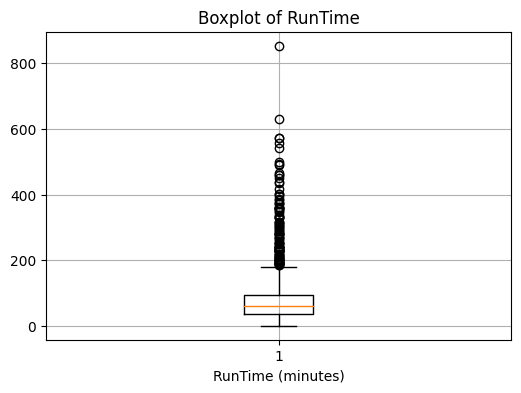

In [38]:


# Drop NaN values to avoid plotting errors
plt.figure(figsize=(6, 4))
plt.boxplot(df['RunTime'].dropna())
plt.title('Boxplot of RunTime')
plt.xlabel('RunTime (minutes)')
plt.grid(True)
plt.show()


In [39]:
df['RunTime'] = df.groupby(df['GENRE'].replace(',','',regex=True).str.strip())['RunTime'].transform(lambda x: x.fillna(x.median()))
# remaining values
df['RunTime']=df['RunTime'].fillna(df['RunTime'].median())
df['RunTime']

0        93.0
1        87.0
2        94.0
3       106.0
4        64.0
        ...  
9989     66.0
9992     66.0
9993     66.0
9994     66.0
9995     66.0
Name: RunTime, Length: 9568, dtype: float64

In [40]:
df.isna().sum()

MOVIES      0
YEAR        0
GENRE       0
RATING      0
ONE-LINE    0
VOTES       0
RunTime     0
Gross       0
Director    0
Stars       0
dtype: int64

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9568 entries, 0 to 9995
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9568 non-null   object 
 1   YEAR      9568 non-null   Int64  
 2   GENRE     9568 non-null   object 
 3   RATING    9568 non-null   float64
 4   ONE-LINE  9568 non-null   object 
 5   VOTES     9568 non-null   float64
 6   RunTime   9568 non-null   float64
 7   Gross     9568 non-null   float64
 8   Director  9568 non-null   object 
 9   Stars     9568 non-null   object 
dtypes: Int64(1), float64(4), object(5)
memory usage: 831.6+ KB


In [42]:
df.describe()

,YEAR,RATING,VOTES,RunTime,Gross
count,9568.0,9568.000000,9.568000e+03,9568.000000,9.568000e+03
mean,2016.581626,6.951772,1.292847e+04,67.485734,9.002353e+06
std,7.340188,1.144610,6.498853e+04,43.052991,1.989297e+07
min,1932.0,1.100000,0.000000e+00,1.000000,0.000000e+00
25%,2016.0,6.400000,6.400000e+01,41.000000,8.550000e+06
50%,2018.0,7.100000,4.895000e+02,60.000000,8.550000e+06
75%,2020.0,7.700000,2.903000e+03,92.000000,8.550000e+06
max,2023.0,9.900000,1.713028e+06,853.000000,5.040100e+08


In [43]:
Q1 = df['RunTime'].quantile(0.25)
Q3 = df['RunTime'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['RunTime'] >= lower) & (df['RunTime'] <= upper)]

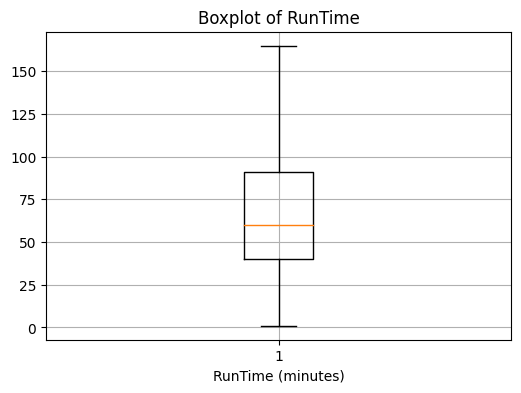

In [44]:

plt.figure(figsize=(6, 4))
plt.boxplot(df['RunTime'])
plt.title('Boxplot of RunTime')
plt.xlabel('RunTime (minutes)')
plt.grid(True)
plt.show()


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9433 entries, 0 to 9995
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9433 non-null   object 
 1   YEAR      9433 non-null   Int64  
 2   GENRE     9433 non-null   object 
 3   RATING    9433 non-null   float64
 4   ONE-LINE  9433 non-null   object 
 5   VOTES     9433 non-null   float64
 6   RunTime   9433 non-null   float64
 7   Gross     9433 non-null   float64
 8   Director  9433 non-null   object 
 9   Stars     9433 non-null   object 
dtypes: Int64(1), float64(4), object(5)
memory usage: 819.9+ KB



# Save new data

In [46]:
df.to_csv('cleaned_movies.csv', index=False)


# Visualization
*Answers of questions*

In [47]:
df_clean=pd.read_csv("cleaned_movies.csv")
df_clean

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,VOTES,RunTime,Gross,Director,Stars
0,Scarface,1932,"Action, Crime, Drama",7.8,An ambitious and nearly insane violent gangste...,26365.0,93.0,8550000.0,"Howard Hawks, Richard Rosson","Paul Muni, Ann Dvorak, Karen Morley, Osgood Pe..."
1,Söderkåkar,1932,Comedy,5.3,The movie version of Gideon Wahlbergs comedy a...,59.0,87.0,8550000.0,Weyler Hildebrand,"Gideon Wahlberg, Dagmar Ebbesen, Björn Berglun..."
2,Kära släkten,1933,Comedy,5.4,The story about a Stockholm wholesaler and his...,36.0,94.0,8550000.0,Gustaf Molander,"Gösta Ekman, Tutta Rolf, Carl Barcklind, Thor ..."
3,Karriär,1938,Drama,5.2,A traveling theater company in Sweden. Conflic...,52.0,106.0,8550000.0,Schamyl Bauman,"Signe Hasso, Sture Lagerwall, Tollie Zellman, ..."
4,Dumbo,1941,"Animation, Adventure, Drama",7.2,"Ridiculed because of his enormous ears, a youn...",124409.0,64.0,1600000.0,"Samuel Armstrong, Norman Ferguson, Wilfred Jac...","Sterling Holloway, Edward Brophy, Herman Bing,..."
...,...,...,...,...,...,...,...,...,...,...
9428,Pretty Smart,2023,Comedy,7.1,Unknown,0.0,66.0,0.0,Pamela Fryman,"Cinthya Carmona, Olivia Macklin, Emily Osment,..."
9429,Pretty Smart,2023,Comedy,7.0,Unknown,0.0,66.0,0.0,Not Known,"Cinthya Carmona, Olivia Macklin, Emily Osment,..."
9430,Pretty Smart,2023,Comedy,7.0,Unknown,0.0,66.0,0.0,Not Known,"Robert Belushi, Cinthya Carmona, Olivia Mackli..."
9431,Pretty Smart,2023,Comedy,7.0,Unknown,0.0,66.0,0.0,Not Known,"Cinthya Carmona, Santana Dempsey, David Gridle..."


## 1. What are the top 10 highest-rated movies?

In [48]:
top_10= df.sort_values(by='RATING', ascending=False).head(10)
top_10[['MOVIES', 'YEAR', 'RATING']]


,MOVIES,YEAR,RATING
472,Avatar: The Last Airbender,2005,9.9
1787,BoJack Horseman,2014,9.9
636,Dexter,2006,9.8
473,Avatar: The Last Airbender,2005,9.8
4343,She-Ra and the Princesses of Power,2018,9.7
3157,Dark,2017,9.7
4287,She-Ra and the Princesses of Power,2018,9.7
6987,The Midnight Gospel,2020,9.7
454,Avatar: The Last Airbender,2005,9.7
552,Meerkat Manor,2005,9.6


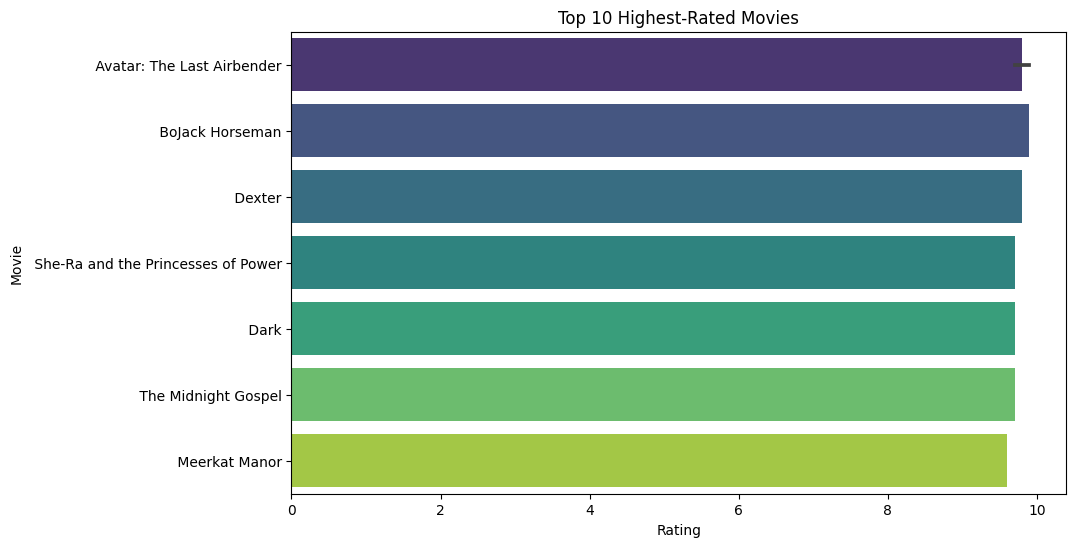

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, y='MOVIES', x='RATING', palette='viridis')
plt.title("Top 10 Highest-Rated Movies")
plt.xlabel("Rating")
plt.ylabel("Movie")
plt.show()


## 2. What is the distribution of movie ratings?

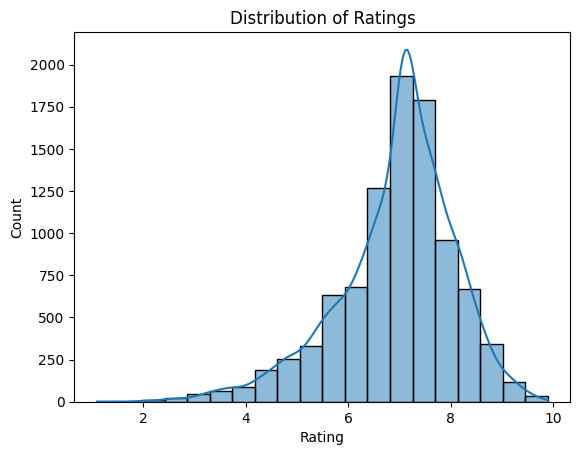

In [50]:
sns.histplot(df['RATING'], bins=20, kde=True)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


## 3. Which genres are the most common?

In [51]:

from collections import Counter

all_genres = df_clean['GENRE'].str.split(', ')
genres = []
for sublist in all_genres:
     if isinstance(sublist, list): 
         for genre in sublist:
            genres.append(genre)

genre_count=Counter(genres)

genre_count


Counter({'Action': 2096,
         'Crime': 1473,
         'Drama': 4044,
         'Comedy': 2725,
         'Animation': 1578,
         'Adventure': 1572,
         'Documentary': 1173,
         'Short': 247,
         'History': 325,
         'War': 47,
         'Romance': 828,
         'Western': 23,
         'Film-Noir': 12,
         'Mystery': 820,
         'Thriller': 887,
         'Fantasy': 533,
         'Horror': 512,
         'Sci-Fi': 298,
         'Musical': 60,
         'Family': 441,
         'Music': 195,
         'Biography': 294,
         'Game-Show': 98,
         'Reality-TV': 369,
         'Sport': 184,
         'News': 22,
         'Talk-Show': 88})

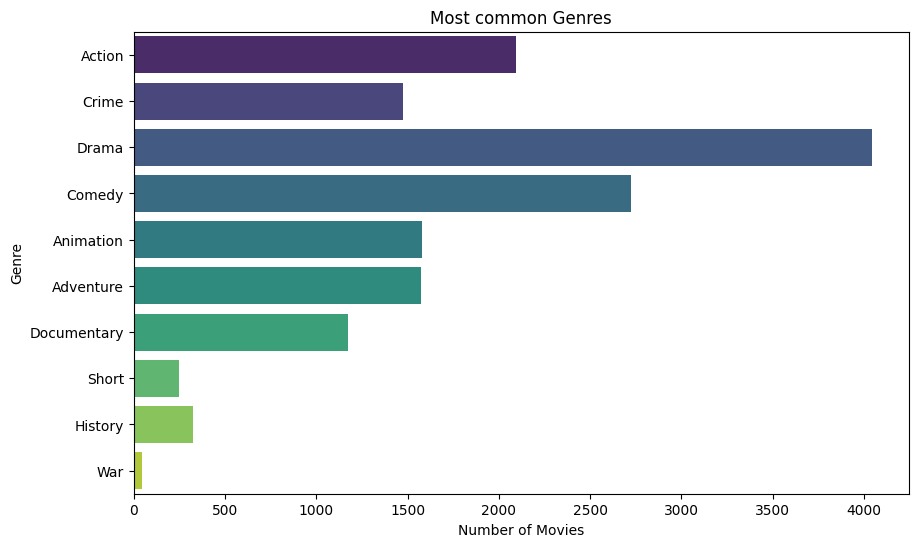

In [52]:
plt.figure(figsize=(10,6))
df_vis = pd.DataFrame(genre_count.items(), columns=['Genre', 'Count'])
sns.barplot(data=df_vis.head(10),y='Genre',x='Count',palette='viridis')
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Most common Genres")
plt.show()

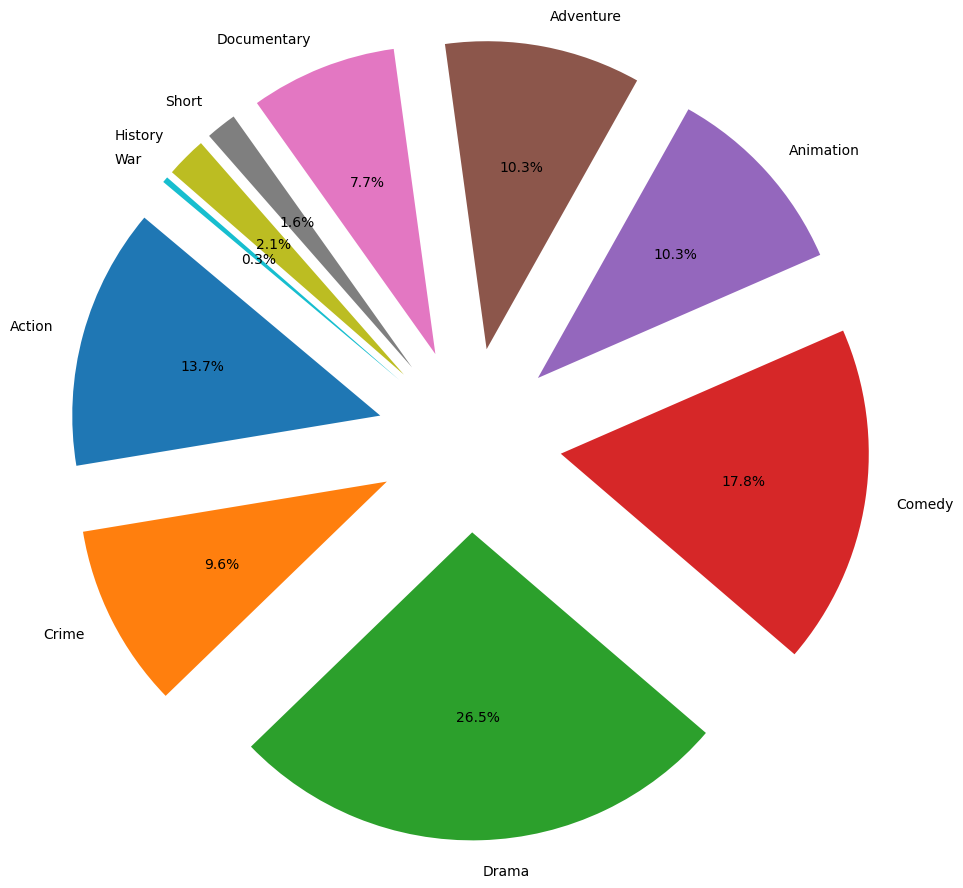

In [53]:
plt.figure(figsize=(10,10))
plt.pie(df_vis['Count'].head(10),labels=df_vis['Genre'].head(10),autopct='%1.1f%%', startangle=140,explode =[.3]*10)
plt.show()

## 4. How does the runtime of movies vary across genres?

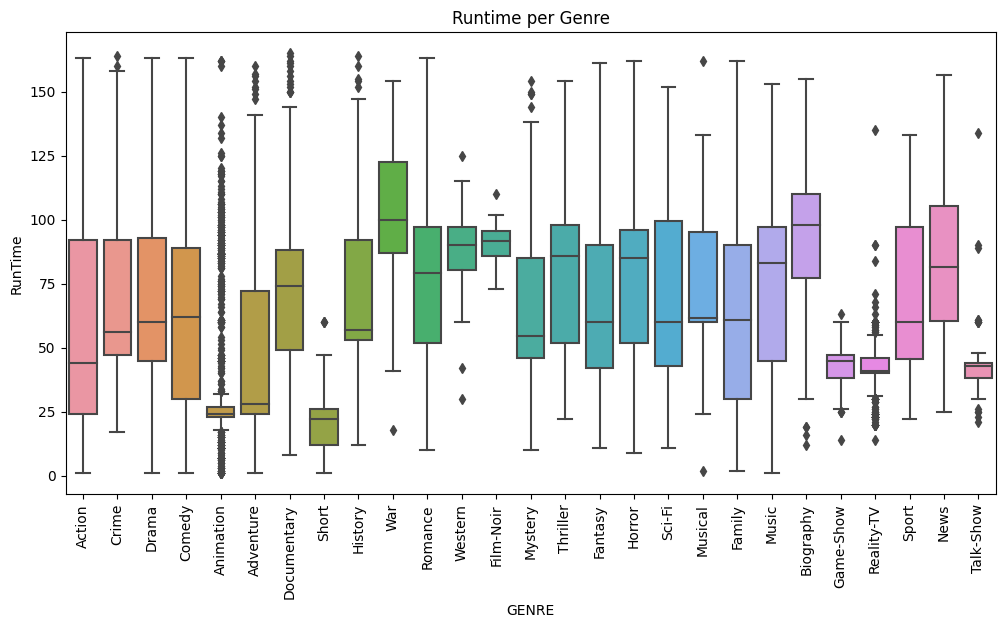

In [54]:
df_explode = df_clean.dropna(subset=['GENRE']).copy()
df_explode['GENRE'] = df_explode['GENRE'].str.split(', ')
df_explode = df_explode.explode('GENRE')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_explode, x='GENRE', y='RunTime')
plt.xticks(rotation=90)
plt.title("Runtime per Genre")
plt.show()


## 5. What is the relationship between votes and gross ?

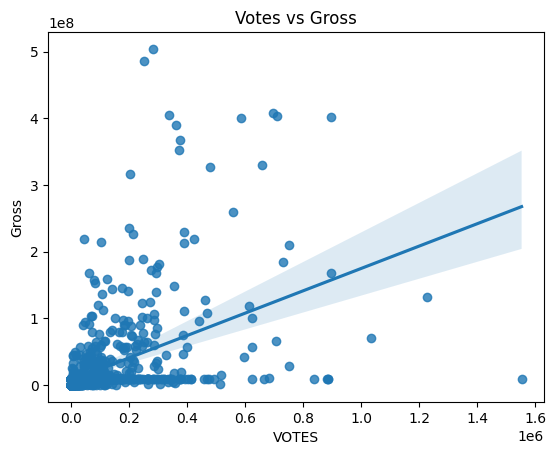

In [55]:
sns.regplot(data=df_clean, x='VOTES', y='Gross',x_jitter=0.1)
plt.title("Votes vs Gross")
plt.show()


## 6.Which directors have the most movies?

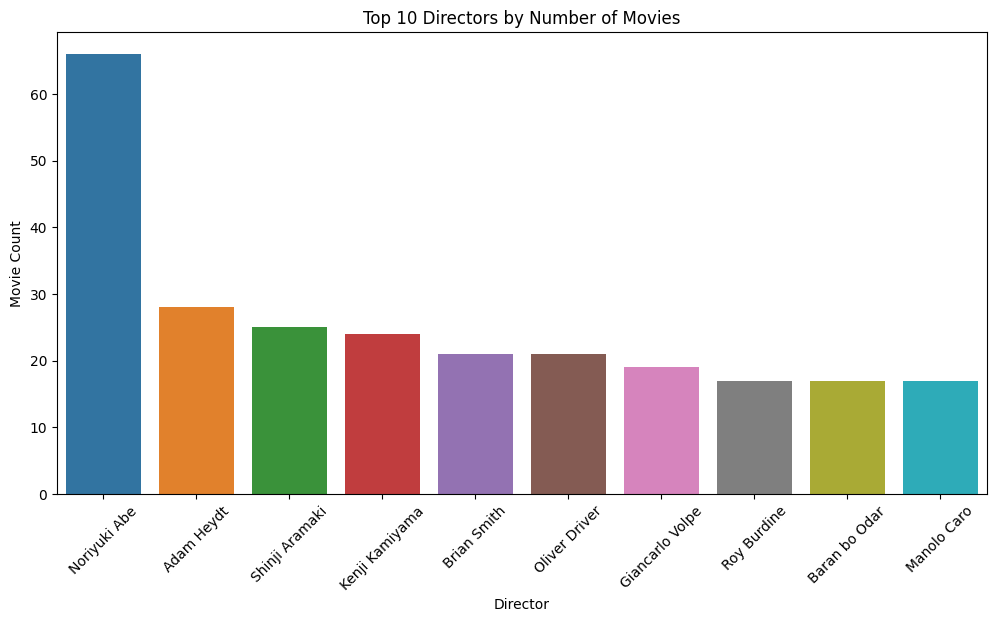

In [56]:
df_explode2 = df_clean.dropna(subset=['Director']).copy()
df_explode2['Director'] = df_explode2['Director'].str.split(', ')
df_explode2 = df_explode2.explode('Director')

top_directors = (
    df_explode2[df_explode2['Director'] != "Not Known"]['Director']
    .value_counts()
    .head(10)
    .reset_index()
)
top_directors.columns = ['Director', 'Movie Count']

plt.figure(figsize=(12, 6))
sns.barplot(data=top_directors, x='Director', y='Movie Count')
plt.title("Top 10 Directors by Number of Movies")
plt.xticks(rotation=45)
plt.show()


## 7. Are there trends in movie production across years?

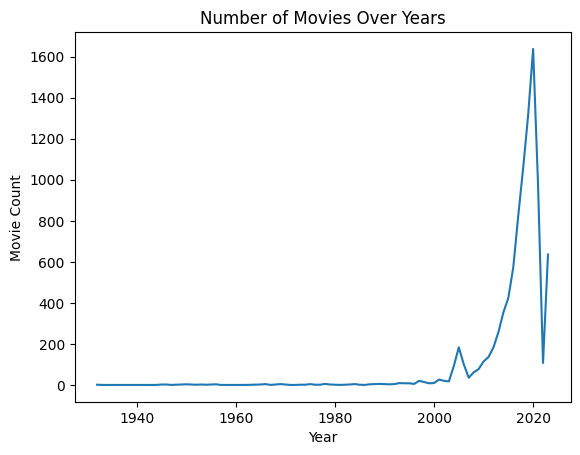

In [57]:
df_clean['YEAR'].value_counts().sort_index().plot(kind='line', title='Number of Movies Over Years')
plt.ylabel("Movie Count")
plt.xlabel("Year")
plt.show()


## 8. What is the average rating per genre?

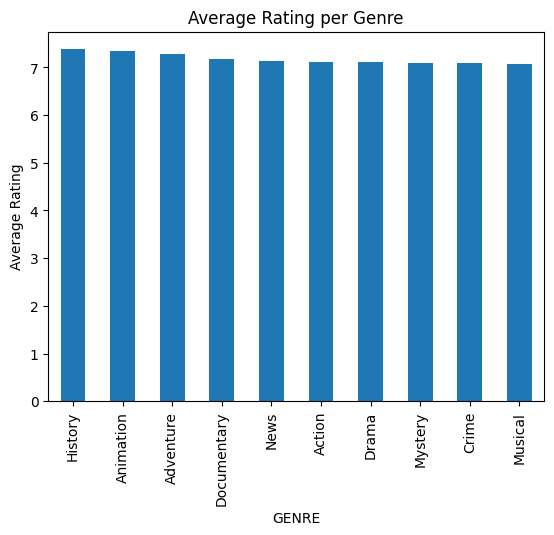

In [58]:
genre_rating = df_explode.groupby('GENRE')['RATING'].mean().sort_values(ascending=False).head(10)
genre_rating.plot(kind='bar', title='Average Rating per Genre')
plt.ylabel("Average Rating")
plt.show()


## 9. Which stars appear most frequently?

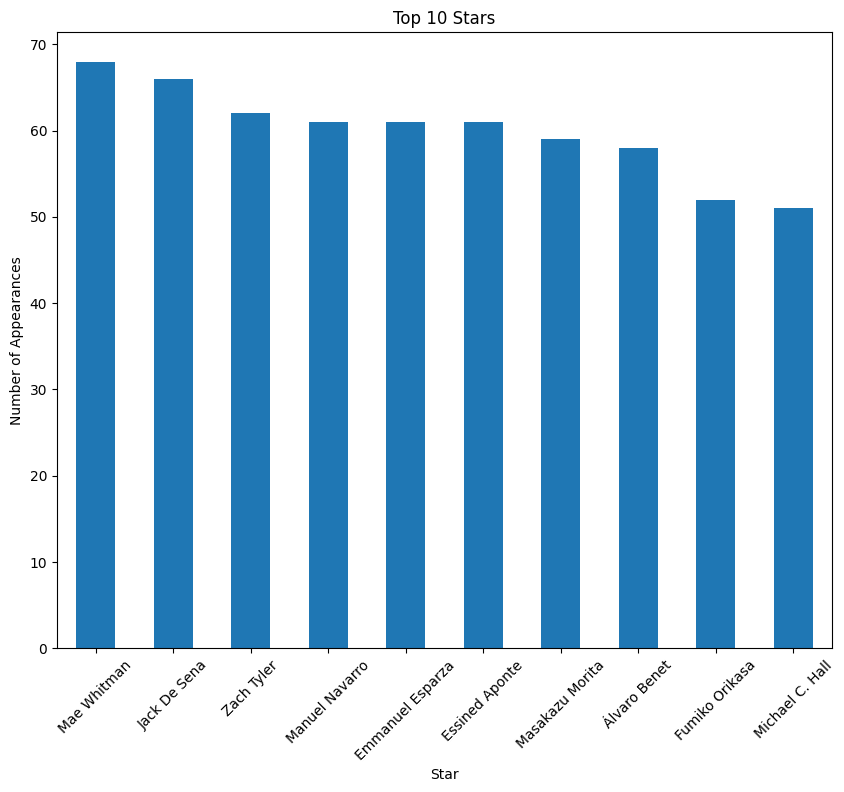

In [59]:
plt.figure(figsize=(10,8))
df_stars = df_clean.dropna(subset=['Stars']).copy()
df_stars['Stars'] = df_stars['Stars'].str.split(', ')
df_stars = df_stars.explode('Stars')
top_stars = df_stars['Stars'].value_counts().head(10)

top_stars.plot(kind='bar', title='Top 10 Stars')
plt.ylabel("Number of Appearances")
plt.xlabel("Star")
plt.xticks(rotation=45)
plt.show()


## 10. Is there correlation between runtime and rating?

In [60]:
cor=df_clean[['RATING','RunTime']].corr()
cor

,RATING,RunTime
RATING,1.00000,-0.32234
RunTime,-0.32234,1.00000


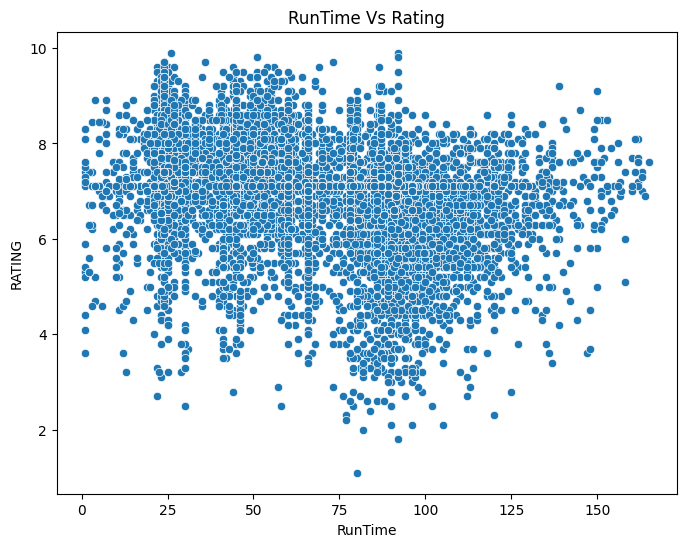

In [61]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_clean,x='RunTime',y='RATING')
plt.title("RunTime Vs Rating")
plt.show()

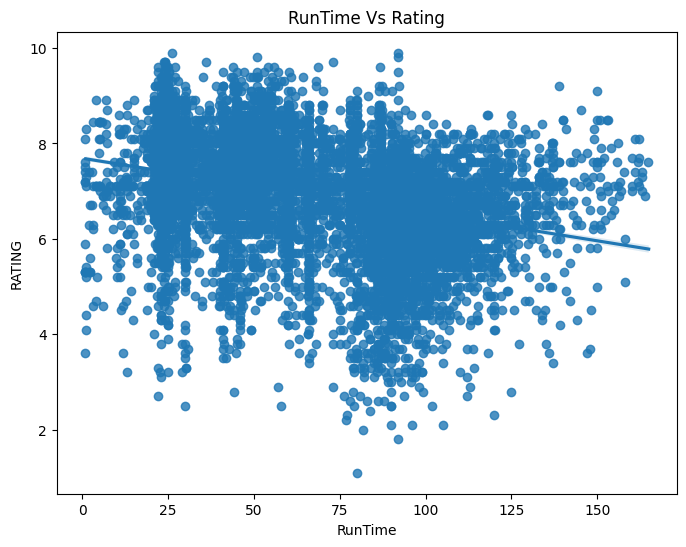

In [62]:
plt.figure(figsize=(8,6))
sns.regplot(data=df_clean,x='RunTime',y='RATING',x_jitter=.2)
plt.title("RunTime Vs Rating")
plt.show()

## 11.What is the distribution of gross revenue?

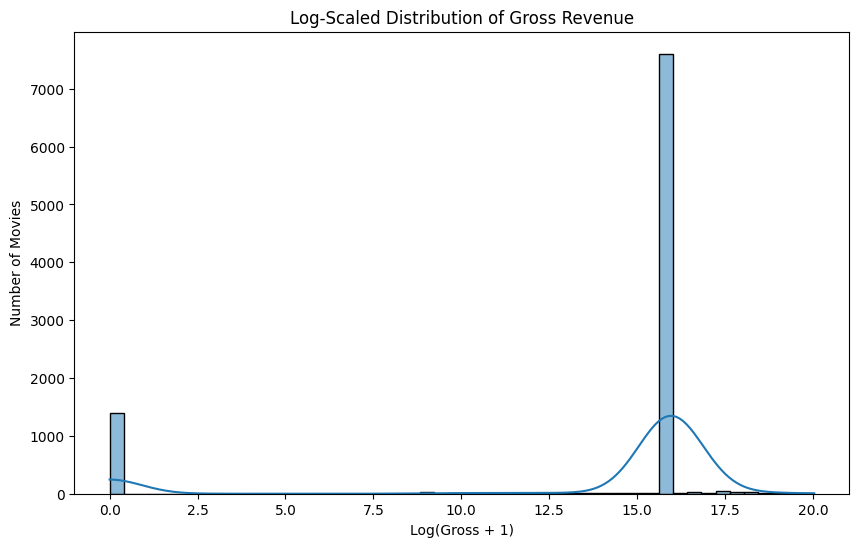

In [63]:
# Log transformation for better view

plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df_clean['Gross']), bins=50, kde=True)
plt.title("Log-Scaled Distribution of Gross Revenue")
plt.xlabel("Log(Gross + 1)")
plt.ylabel("Number of Movies")
plt.show()


## 12. Are there outliers in votes or gross revenue?

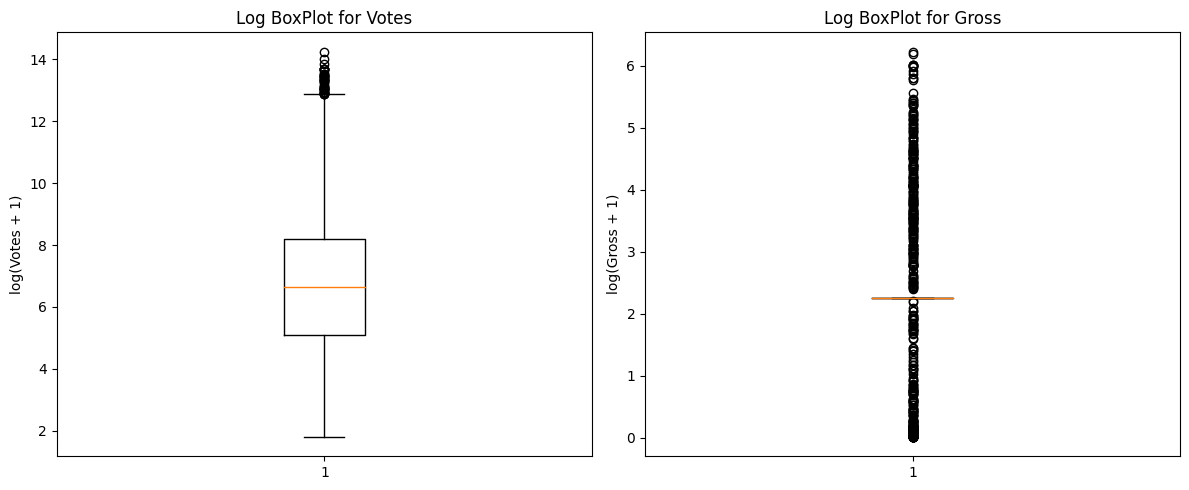

In [64]:

votes_filtered = df_clean[df_clean['VOTES'] > 0]['VOTES']
gross_filtered = df_clean[df_clean['Gross'] > 0]['Gross']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(np.log1p(votes_filtered))
axes[0].set_title('Log BoxPlot for Votes')
axes[0].set_ylabel('log(Votes + 1)')

axes[1].boxplot(np.log1p(gross_filtered/1_000_000))
axes[1].set_title('Log BoxPlot for Gross')
axes[1].set_ylabel('log(Gross + 1)')

plt.tight_layout()
plt.show()


## 13. Do certain genres tend to have higher ratings?

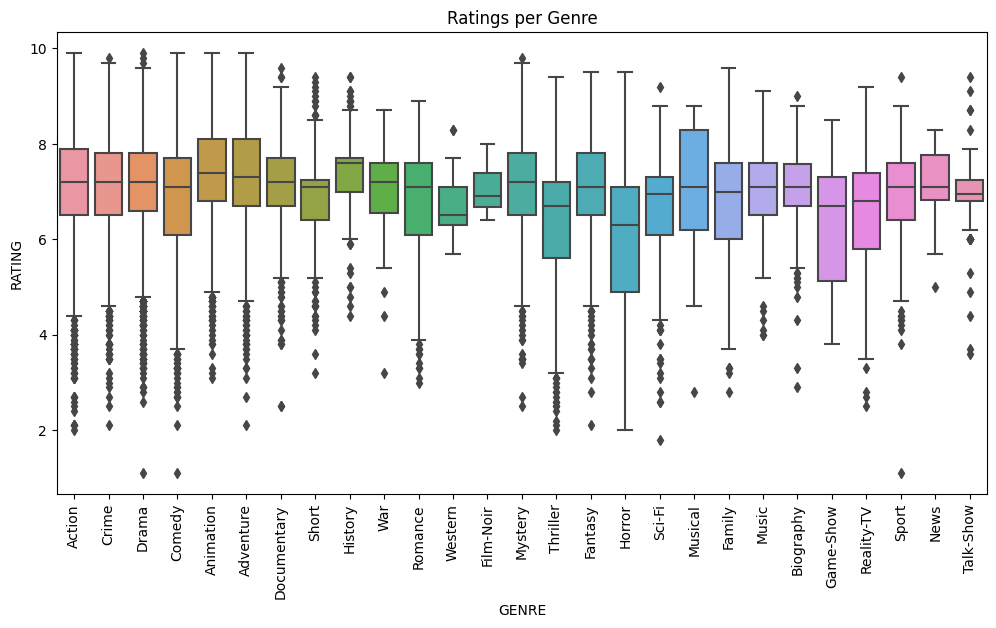

In [65]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_explode, x='GENRE', y='RATING')
plt.xticks(rotation=90)
plt.title("Ratings per Genre")
plt.show()


## 14.Are newer movies rated better or worse than older ones?

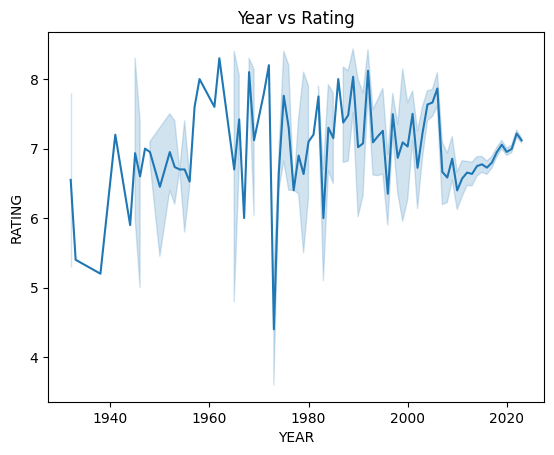

In [66]:
sns.lineplot(data=df_clean, x='YEAR', y='RATING')
plt.title("Year vs Rating")
plt.show()


## 15. What genres have the highest grossing?

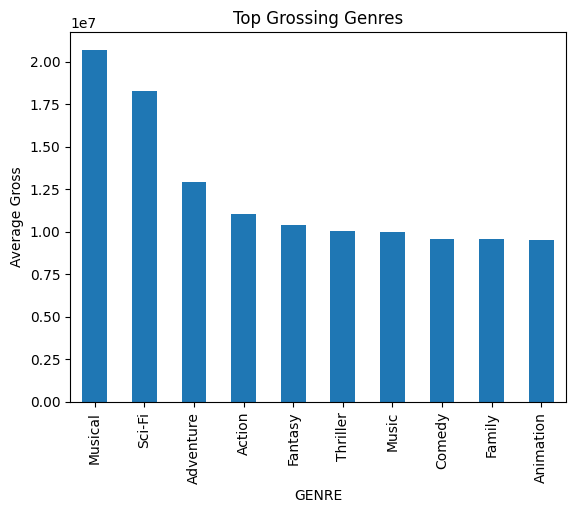

In [67]:
genre_gross = df_explode.groupby('GENRE')['Gross'].mean().sort_values(ascending=False).head(10)
genre_gross.plot(kind='bar', title='Top Grossing Genres')
plt.ylabel("Average Gross")
plt.show()


## 16. Which years had the highest Gross?

In [68]:
top_years=df_clean.groupby(['YEAR'])['Gross'].sum().sort_values(ascending=False).head(10)
top_years

YEAR
2020    1.267580e+10
2019    1.169186e+10
2018    9.408530e+09
2017    9.191920e+09
2016    6.628280e+09
2021    5.728500e+09
2015    4.100590e+09
2013    3.776710e+09
2014    3.398780e+09
2012    2.222610e+09
Name: Gross, dtype: float64

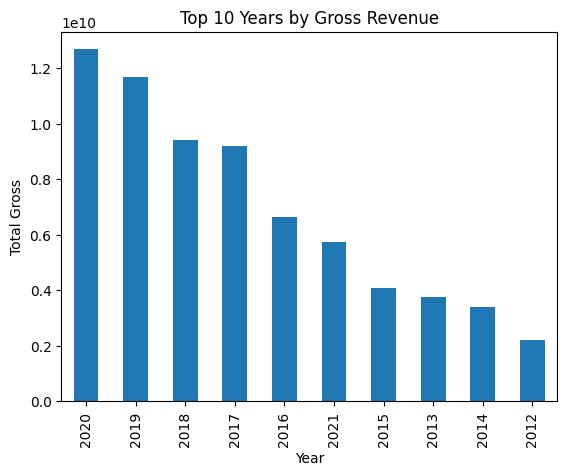

In [69]:
top_years.plot(kind='bar', title='Top 10 Years by Gross Revenue')
plt.ylabel('Total Gross')
plt.xlabel('Year')
plt.show()

## Correlation between columns

In [70]:
num_cols = df_clean.select_dtypes(include='number').columns
num_cols

Index(['YEAR', 'RATING', 'VOTES', 'RunTime', 'Gross'], dtype='object')

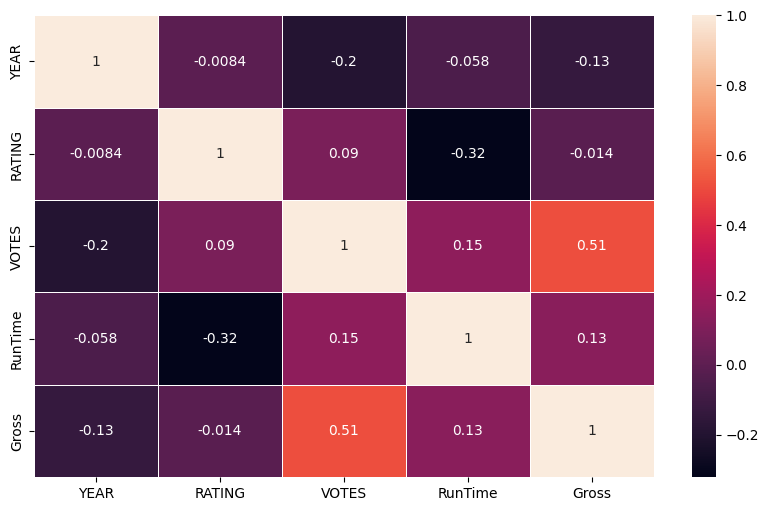

In [71]:
corr = df_clean[num_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True,linewidths=.5)
plt.show()